In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set()

In [2]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_dataset.csv to synthetic_dataset.csv


In [3]:
df = pd.read_csv("synthetic_dataset.csv")

print("First 5 rows:")
display(df.head())



First 5 rows:


,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0


**Task 1: Data Quality Issues**

In [4]:
# Shape
print("Shape:", df.shape)

# Missing values
print("\nMissing Values:\n", df.isna().sum())

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Data types
print("\nData Types:\n", df.dtypes)

Shape: (4362, 5)

Missing Values:
 Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64

Duplicate rows: 15

Data Types:
 Category     object
Price       float64
Rating      float64
Stock        object
Discount    float64
dtype: object


The dataset was examined to identify potential data quality issues. The analysis revealed the presence of missing values in several columns and duplicate records. Such issues can negatively affect data analysis and machine learning models if left untreated. Therefore, data cleaning is necessary before proceeding with further preprocessing steps.


**Task 2: Handle Missing Values**

Before Cleaning

In [5]:
print("BEFORE CLEANING :")
print(df.isna().sum())

BEFORE CLEANING :
Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64


Cleaning Process

In [6]:
df['Category'] = df['Category'].fillna('Unknown')
df['Stock'] = df['Stock'].fillna('Unknown')

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

df['Price'] = df['Price'].fillna(df['Price'].median())
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Discount'] = df['Discount'].fillna(df['Discount'].median())

df = df.drop_duplicates()

After Cleaning

In [7]:
print("AFTER CLEANING :")
print("Missing Values:")
print(df.isna().sum())

print("\nShape after cleaning:")
print(df.shape)

print("\nSample data:")
display(df.head())

AFTER CLEANING :
Missing Values:
Category    0
Price       0
Rating      0
Stock       0
Discount    0
dtype: int64

Shape after cleaning:
(4345, 5)

Sample data:


,Category,Price,Rating,Stock,Discount
0,Unknown,5548.0,1.870322,Unknown,0.0
1,Unknown,3045.0,4.757798,Unknown,38.0
2,Unknown,4004.0,3.082060,In Stock,0.0
3,Unknown,4808.0,1.492085,Unknown,33.0
4,Unknown,1817.0,3.082060,Out of Stock,23.0


Missing values were handled using median imputation for numerical features (Price, Rating, and Discount) and the value "Unknown" for categorical features (Category and Stock). The median was selected because it is less sensitive to extreme values than the mean. After preprocessing, all missing values were successfully removed, and duplicate rows were eliminated, improving the overall quality of the dataset.


**Task 3: Outliers (IQR Method)**

Before Outlier Removal

In [8]:
print("Shape before outliers removal:", df.shape)

Shape before outliers removal: (4345, 5)


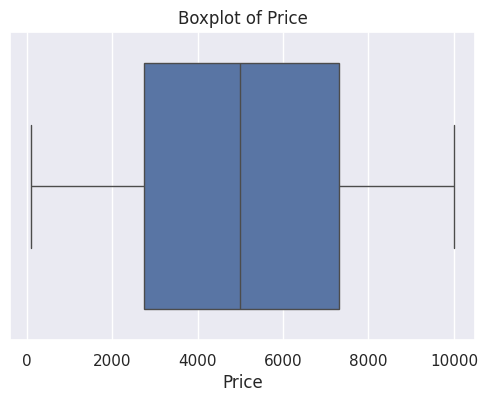

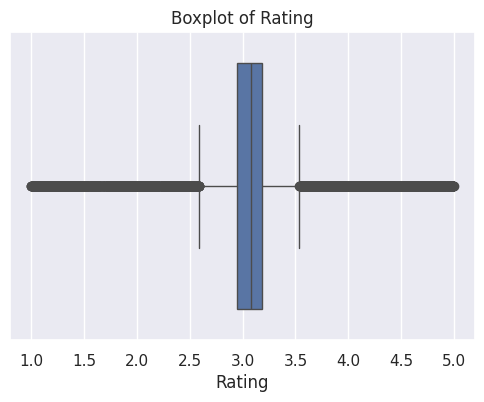

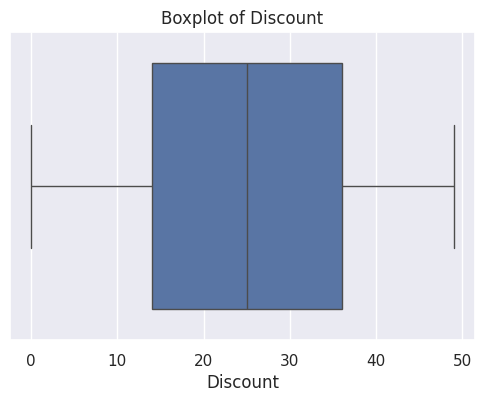

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Price")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Rating'])
plt.title("Boxplot of Rating")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Discount'])
plt.title("Boxplot of Discount")
plt.show()

The boxplots provide a visual representation of potential outliers in the dataset. Values appearing outside the whiskers may be considered extreme observations. These observations can affect statistical measures and machine learning models if not handled appropriately.


IQR Method

In [10]:

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Price'] >= Q1 - 1.5*IQR) & (df['Price'] <= Q3 + 1.5*IQR)]


Q1 = df['Discount'].quantile(0.25)
Q3 = df['Discount'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Discount'] >= Q1 - 1.5*IQR) & (df['Discount'] <= Q3 + 1.5*IQR)]


After Outlier Removal

In [11]:
print("Shape after removing outliers:", df.shape)

print("\nSummary statistics:")
display(df.describe())

Shape after removing outliers: (4345, 5)

Summary statistics:


,Price,Rating,Discount
count,4345.000000,4345.000000,4345.000000
mean,5016.230955,3.058771,24.558803
std,2788.194060,0.834024,13.686718
min,102.000000,1.000366,0.000000
25%,2735.000000,2.945174,14.000000
50%,4996.500000,3.082060,25.000000
75%,7316.000000,3.181728,36.000000
max,9999.000000,4.997818,49.000000


The Interquartile Range (IQR) method was used to identify potential outliers in the numerical features. Outliers are observations that fall outside the expected statistical range and may influence analytical results. After applying the IQR method, the dataset maintained a reasonable number of records while reducing the effect of extreme observations. This helps improve the reliability of subsequent preprocessing and analysis steps.


**Task 4: Normalization**

Min-Max Scaling

In [12]:

minmax = MinMaxScaler()

df[['Price_MinMax', 'Rating_MinMax', 'Discount_MinMax']] = minmax.fit_transform(
    df[['Price', 'Rating', 'Discount']]
)

df[['Price_MinMax', 'Rating_MinMax', 'Discount_MinMax']].head()

,Price_MinMax,Rating_MinMax,Discount_MinMax
0,0.550268,0.217628,0.000000
1,0.297363,0.939957,0.775510
2,0.394261,0.520755,0.000000
3,0.475498,0.123008,0.673469
4,0.173285,0.520755,0.469388


Min-Max normalization was applied to scale numerical features into the range between 0 and 1. This transformation ensures that features with larger numerical values do not dominate those with smaller values. The relative ordering of observations remains unchanged while making all features comparable on the same scale.


Z-Score Standardization

In [13]:

scaler = StandardScaler()

df[['Price_Z', 'Rating_Z', 'Discount_Z']] = scaler.fit_transform(
    df[['Price', 'Rating', 'Discount']]
)

df[['Price_Z', 'Rating_Z', 'Discount_Z']].head()

,Price_Z,Rating_Z,Discount_Z
0,0.190744,-1.425122,-1.794560
1,-0.707073,2.037379,0.982174
2,-0.363084,0.027927,-1.794560
3,-0.074692,-1.878683,0.616815
4,-1.147553,0.027927,-0.113905


Z-score standardization was applied to transform numerical features so that they have a mean close to 0 and a standard deviation close to 1. Positive values indicate observations above the mean, while negative values indicate observations below the mean. This technique is particularly useful for algorithms that are sensitive to feature scaling, such as PCA.


**Task 5: PCA**

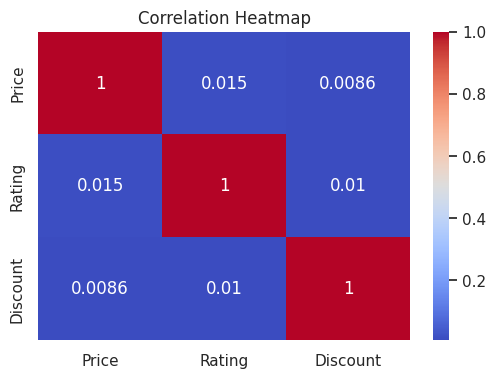

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df[['Price','Rating','Discount']].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap was used to examine relationships among the numerical variables. Correlation values close to 1 or -1 indicate strong linear relationships, whereas values close to 0 indicate weak relationships. Understanding these relationships is useful before applying dimensionality reduction techniques such as PCA.


In [15]:
from sklearn.decomposition import PCA

X = df[['Price_Z', 'Rating_Z', 'Discount_Z']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.34096221 0.33074114]


In [16]:
print("PCA transformed data (first 5 rows):")
print(principal_components[:5])

PCA transformed data (first 5 rows):
[[-1.68448685 -1.26320767]
 [ 1.3439965   0.66572151]
 [-1.11173697 -1.35968711]
 [-0.89814446  1.01884982]
 [-0.72456904  0.43434753]]


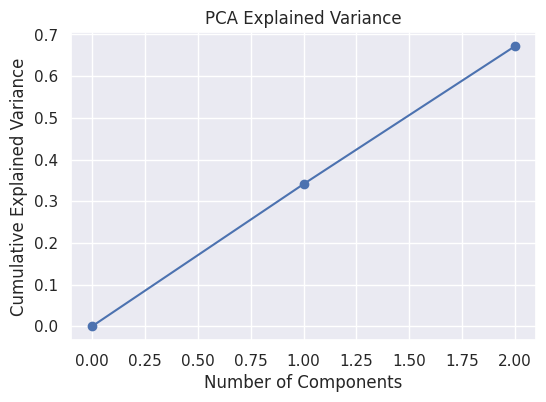

In [17]:
plt.figure(figsize=(6,4))
plt.plot(
    np.insert(np.cumsum(pca.explained_variance_ratio_),0,0),
    marker='o'
)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

**PCA Output**

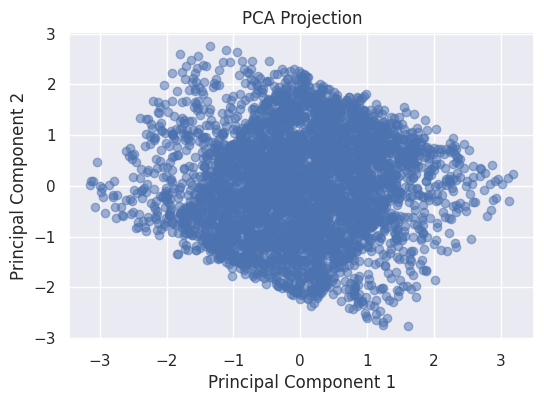

In [18]:

plt.figure(figsize=(6,4))
plt.scatter(
    principal_components[:,0],
    principal_components[:,1],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.grid(True)
plt.show()

**Explained Variance Ratio:**

PC1: ≈ 34.10%

PC2: ≈ 33.07%

**Interpretation:**

The Principal Component Analysis (PCA) was applied to the standardized numerical features (Price_Z, Rating_Z, and Discount_Z). The results show that the first principal component (PC1) explains approximately 34.10% of the total variance, while the second principal component (PC2) explains approximately 33.07%.

Together, the first two principal components capture about 67.17% of the total variance in the dataset. This indicates that a substantial amount of information can be retained using only two components, reducing the dimensionality of the dataset while preserving most of its important patterns.

The relatively balanced distribution of variance between PC1 and PC2 suggests that the information in the dataset is spread across multiple dimensions rather than being dominated by a single feature. Therefore, both principal components contribute meaningfully to representing the underlying structure of the data.

**PCA Transformed Data:**

The transformed dataset represents the original numerical features in a new orthogonal coordinate system defined by the principal components. This transformation reduces redundancy among features and creates uncorrelated variables while preserving most of the important information contained in the original dataset.

Using the first two principal components retains approximately 67.17% of the total variance, providing a lower-dimensional representation of the data with limited information loss.


In [19]:
df.to_csv("Assignment2_Cleaned_ZahraAlrowaei.csv", index=False)

print("File saved successfully!")

File saved successfully!
